# Can an Algorithm Spot a Cyberattack Without Ever Being Told What One Looks Like?

### A Clustering Experiment on 175,000 Real Network Connections

Imagine handing someone a huge spreadsheet of network traffic - how long each connection lasted, how much data went back and forth, which network protocol it used - but you **cross out the column that says 'attack' or 'normal.'** Could they still figure out which rows look suspicious, just from the numbers themselves?

That's exactly what we're testing here, using **K-Means clustering** - an *unsupervised* machine learning technique that groups similar rows together without ever being told what the "right" groups are.

This notebook is built around one central, slightly mischievous idea:

> **We're going to run the exact same experiment four times, changing one small thing each time - and get four genuinely different answers to "did the algorithm find the attacks?"** Sometimes the answer will look like a spectacular success. Sometimes that "success" will turn out to be an illusion. That gap between *looks impressive* and *is actually true* is the real subject of this notebook.

### What You'll See
1. **Meet the data** - a quick, visual tour of 175,341 network connections
2. **Prepare the data** - and explain exactly what we're hiding from the algorithm, and why
3. **Experiment A** - cluster the raw numbers, unscaled. Get a suspiciously perfect-looking score.
4. **Experiment B** - scale the numbers first. Watch the "perfect" score fall apart into something more honest.
5. **Experiment C** - add in network protocol information. See almost nothing change.
6. **Experiment D** - ask a richer question (more groups instead of just 2), and get the most interesting result of the whole notebook.
7. **The verdict** - what this experiment does and does not prove about AI and cybersecurity.

No machine learning background required - every technical term gets a plain-English explanation the first time it shows up.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

PALETTE=['#2A9D8F','#E63946','#457B9D','#F4A261','#8E44AD','#264653','#E9C46A','#8AB17D','#606C38']
plt.rcParams['axes.titleweight']='bold'

## Part 1: Meet the Data

We're using the **UNSW-NB15** dataset - a widely-used academic cybersecurity dataset built by capturing real network traffic and mixing in real attack traffic generated in a lab, then labeling every connection as `Normal` or one of 9 specific attack types.

In [3]:
df = pd.read_csv('UNSW_NB15_training-set.csv')
df.shape

(175341, 45)

In [4]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

45 columns, 175,341 rows. Most columns are numeric measurements of a network connection (duration, bytes sent, packets sent, etc.) - a handful describe it in words (`proto`, `service`, `state`), and two are the **answer key** we're going to hide: `label` (0 = Normal, 1 = Attack) and `attack_cat` (the specific attack type, or `Normal`).

In [7]:
df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

**Zero missing values.**

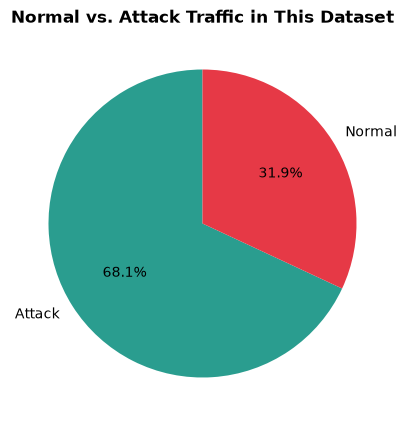

In [8]:
label_counts = df['label'].value_counts().rename({0:'Normal', 1:'Attack'})
plt.figure(figsize=(6,5))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=['#2A9D8F','#E63946'], startangle=90)
plt.title('Normal vs. Attack Traffic in This Dataset')
plt.show()

**Important context before we go further:** in this dataset, **68% of all traffic is labeled an attack.** That is *nothing* like real-world network traffic, where the overwhelming majority of connections are completely normal and actual attacks are a tiny needle in a huge haystack. This dataset was deliberately built this way for research purposes - it's a curated training set, not a snapshot of a real network. Keep this in mind: every result below describes *this dataset*, not "how common cyberattacks are in real life."

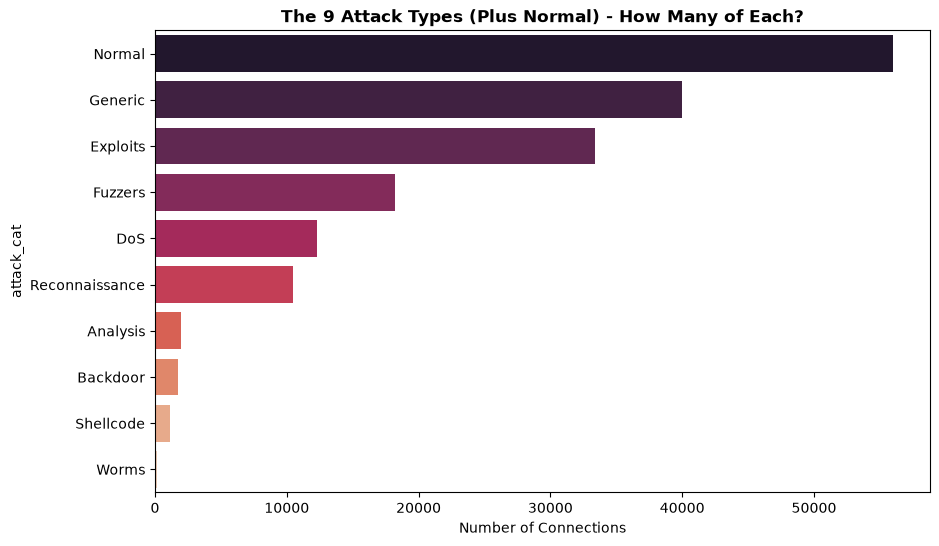

In [9]:
attack_counts = df['attack_cat'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=attack_counts.values, y=attack_counts.index, hue=attack_counts.index, palette='rocket', legend=False)
plt.title('The 9 Attack Types (Plus Normal) - How Many of Each?')
plt.xlabel('Number of Connections')
plt.show()

Huge range here: **Generic** attacks alone make up 40,000 connections, while **Worms** appear only 130 times in the entire dataset. Any pattern we find for Worms specifically should be treated with a lot more caution than a pattern found for Generic - 130 examples just isn't a lot to learn from.

In [10]:
df[['proto', 'service', 'state']].nunique()

proto      133
service     13
state        9
dtype: int64

**Interesting finding here:** the `proto` (network protocol) column has **133 different values.** Most people would guess a handful (TCP, UDP, maybe ICMP) - not 133. Let's see what's actually going on:

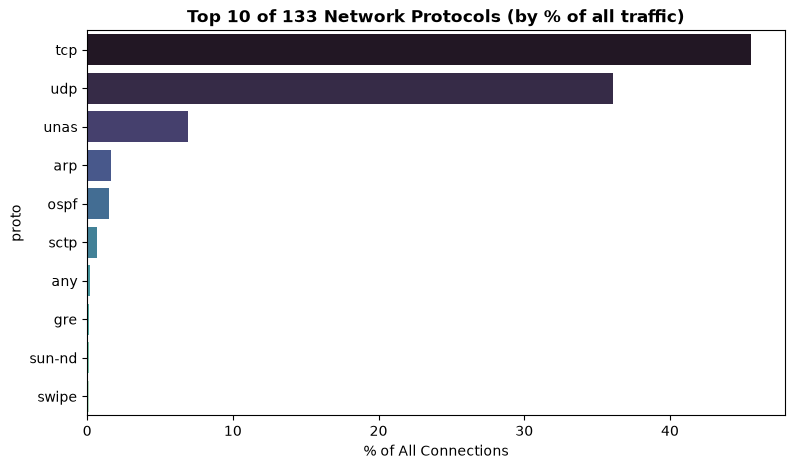

In [11]:
proto_share = df['proto'].value_counts(normalize=True).head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=proto_share.values*100, y=proto_share.index, hue=proto_share.index, palette='mako', legend=False)
plt.title('Top 10 of 133 Network Protocols (by % of all traffic)')
plt.xlabel('% of All Connections')
plt.show()

Just **2 protocols (TCP and UDP) cover over 80% of all traffic**, and the top 8 protocols cover **92.6%** of everything. The other 125+ protocols are rare, or one-off entries. This matters a lot for what comes later: if we naively convert `proto` into 133 separate yes/no columns ( **one-hot encoding**technique), we'd be adding well over a hundred columns to represent information that's 92% redundant. We'll fix that in Part 2.

In [12]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns
numeric_features = [c for c in numeric_columns if c not in ['id','label']]
len(numeric_features)

39

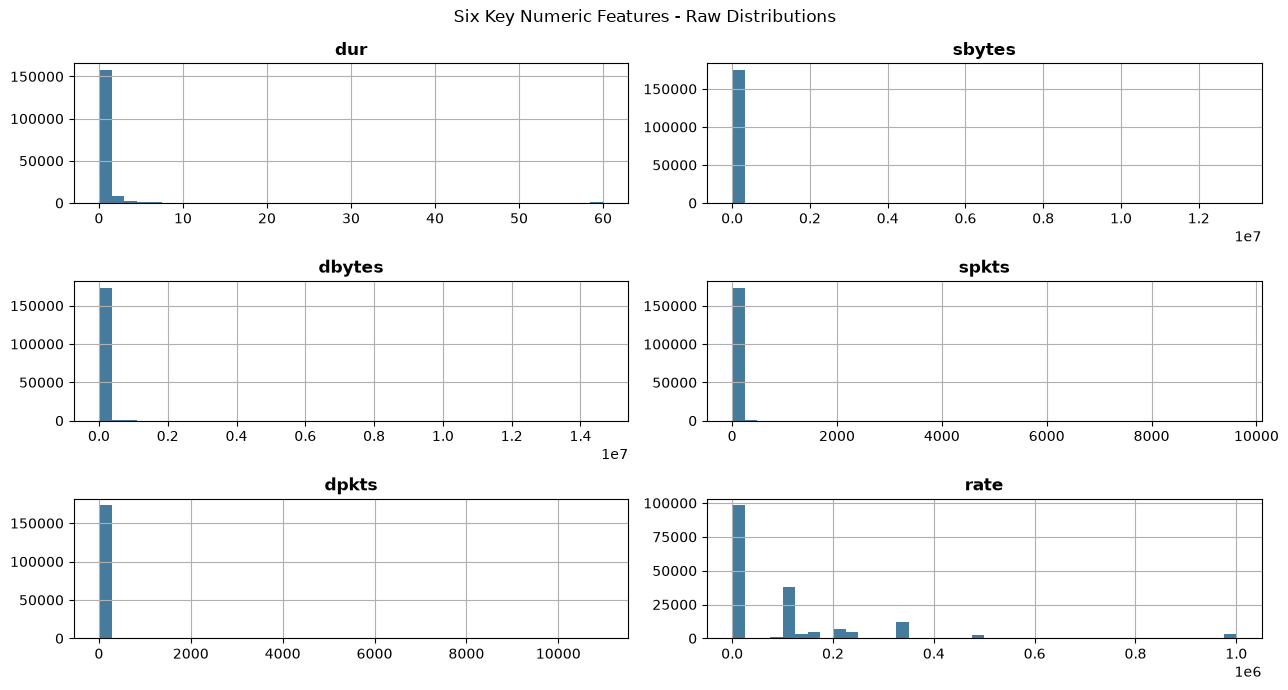

In [13]:
df[['dur','sbytes','dbytes','spkts','dpkts','rate']].hist(figsize=(13,7), bins=40, color='#457B9D')
plt.suptitle('Six Key Numeric Features - Raw Distributions')
plt.tight_layout()
plt.show()

Every single one of these is heavily **right-skewed** - a huge pile of small/typical connections, and a long thin tail of connections that transferred enormous amounts of data or lasted a very long time. This is completely normal for network data, but it's also exactly the kind of shape that causes trouble for distance-based methods like K-Means if we don't scale it - more on that soon.

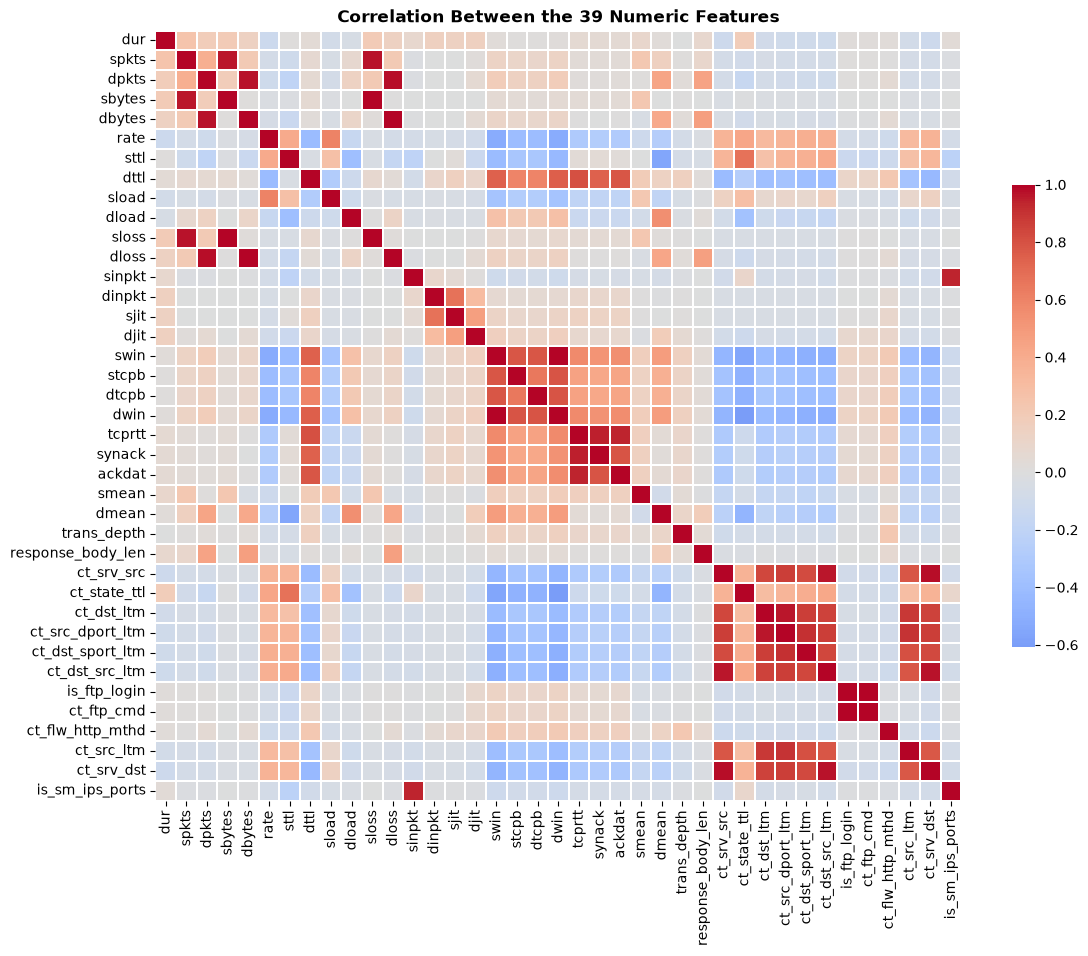

In [14]:
plt.figure(figsize=(13,10))
corr = df[numeric_features].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'shrink':0.6})
plt.title('Correlation Between the 39 Numeric Features')
plt.show()

A lot of dark red blocks - many of these 39 features move together (e.g. bytes sent and packets sent, or the various `ct_*` "how many similar connections recently" counters). We're keeping all of them for this experiment rather than hand-picking a subset, specifically so we can watch what happens when redundant, differently-scaled information all gets thrown at the algorithm at once - which is realistically how this data would arrive in practice.

## Part 2: Preparing the Data

### The One Rule of This Whole Experiment
`label` and `attack_cat` are the answer key. **K-Means will never see either column.** If we accidentally included them, we wouldn't be testing whether clustering can *discover* attacks - we'd just be handing it the answer and asking it to repeat it back. Everything below is built exclusively from the other 42 columns - traffic statistics an algorithm could compute in real time, with no human telling it which rows are dangerous.

In [13]:
top_protocols = df['proto'].value_counts().head(8).index
df['proto_bucketed'] = df['proto'].where(df['proto'].isin(top_protocols), 'other')
df['proto_bucketed'].value_counts()

proto_bucketed
tcp      79946
udp      63283
other    12899
unas     12084
arp       2859
ospf      2595
sctp      1150
any        300
gre        225
Name: count, dtype: int64

This is the fix for the 133-protocol problem from Part 1: keep the 8 protocols that actually make up 92.6% of the traffic, and lump every rare one into a single `other` bucket. We still capture almost all the real signal, without generating well over a hundred mostly-empty columns.

### Why Scaling Is About to Matter So Much
Look back at the histograms above: `sbytes` (bytes sent) ranges into the **millions**, while a field like `is_ftp_login` is just a `0` or a `1`. K-Means decides which rows are "similar" by measuring the **distance** between them, the same way you'd measure distance on a map. If one feature's numbers are a million times bigger than another's, that one feature silently becomes almost the *only* thing the distance calculation cares about - like judging how similar two cities are almost entirely by their zip code, because zip codes happen to be bigger numbers than, say, their average rainfall. `StandardScaler` puts every feature on the same footing before we measure distance. This isn't a rule for *every* machine learning model - tree-based models mostly don't care about scale - but it matters a great deal for anything, like K-Means, that works by measuring distance.

## Experiment A: Cluster the Raw Numbers - No Scaling

Let's do the naive thing first: feed the 39 raw numeric columns straight into K-Means, and ask it for **2 groups** (the obvious guess, since we have Normal vs. Attack in mind - even though the algorithm doesn't know that).

In [14]:
X_numeric = df[numeric_features].copy()
kmeans_unscaled = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_unscaled = kmeans_unscaled.fit_predict(X_numeric)
pd.Series(clusters_unscaled).value_counts()

0    110490
1     64851
Name: count, dtype: int64

In [15]:
silhouette_unscaled = silhouette_score(X_numeric, clusters_unscaled, sample_size=20000, random_state=42)
silhouette_unscaled

0.6848635608099072

### A Silhouette Score of ~0.68
**Quick plain-English definition:** the *silhouette score* measures how neatly separated the groups are, from -1 (badly mixed up) to +1 (perfectly separated, like sorting laundry into obviously-different piles). A score of 0.68 out of a maximum of 1.0 looks fantastic - genuinely one of the best scores you'll see in real-world clustering. If we stopped right here, the headline would practically write itself: 

**"AI discovers cyberattacks with zero training, achieves 0.68 separation score!"**

**Let's check if that headline is actually true.**

In [16]:
results = df[['label','attack_cat']].copy()
results['cluster_unscaled'] = clusters_unscaled
pd.crosstab(results['cluster_unscaled'], results['label'].map({0:'Normal',1:'Attack'}), normalize='index').round(3)

label,Attack,Normal
cluster_unscaled,,
0,0.775,0.225
1,0.520,0.480


Remember, **68% of the whole dataset is already an attack** just by default. So a cluster that's "77.5% attack" is only modestly better than randomly guessing, and a cluster that's "52% attack" is basically a **coin flip**. For a score of 0.68 - which promises near-perfect separation - this is a massive letdown. Something else is clearly driving these two "beautifully separated" clusters, and it isn't attacks.

In [17]:
diag = X_numeric.copy()
diag['cluster'] = clusters_unscaled
diag.groupby('cluster').mean().T.assign(gap=lambda d: (d[0]-d[1]).abs()).sort_values('gap', ascending=False).head(6)

cluster,0,1,gap
stcpb,1.053847e+08,2.441063e+09,2.335678e+09
dtcpb,1.059033e+08,2.439170e+09,2.333267e+09
sload,1.163083e+08,4.409194e+05,1.158674e+08
dload,2.545915e+05,1.381012e+06,1.126421e+06
rate,1.509049e+05,8.500771e+02,1.500549e+05
dbytes,5.075873e+03,3.171606e+04,2.664019e+04


**There's the culprit.** `stcpb` and `dtcpb` (the starting sequence numbers TCP uses internally to track a connection - essentially large, semi-random connection ID numbers with no security meaning at all) differ between the two clusters by **over two billion.** No other feature comes remotely close. K-Means didn't find "attacks" - it found **"connections with a big `stcpb` number" vs. "connections with a small one."** That split happens to correlate weakly with attacks, purely by chance, because certain attack types tend to generate connections a certain way - but it is not a security finding.

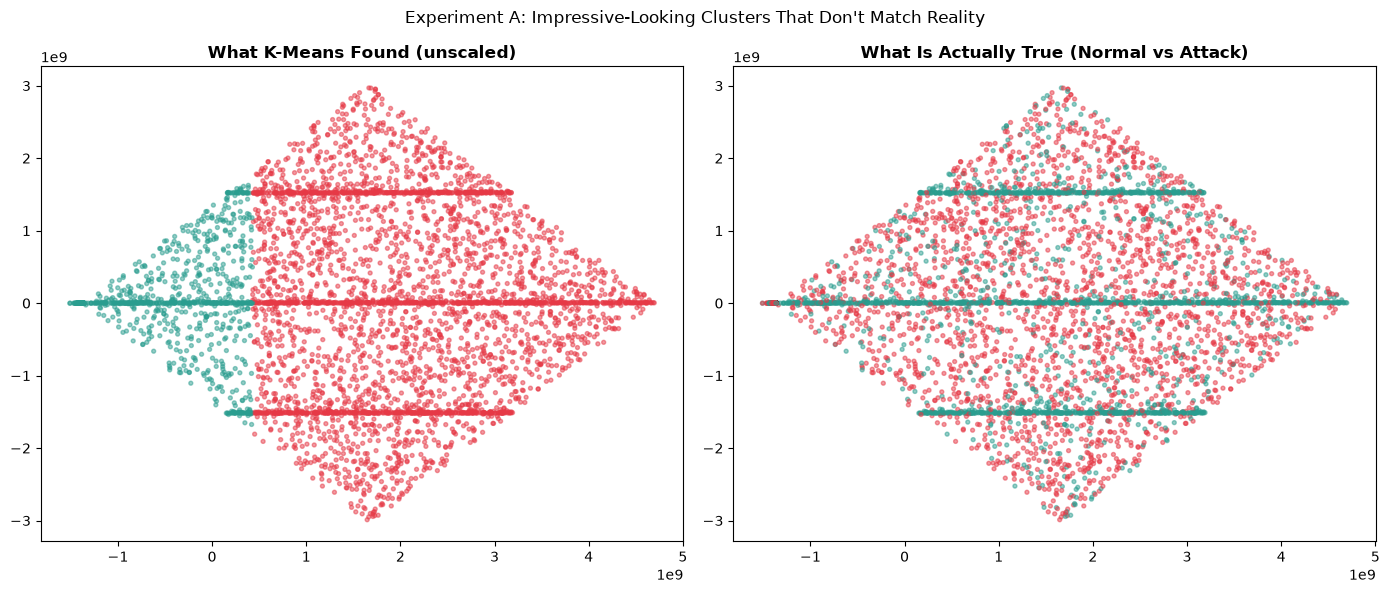

In [18]:
pca_unscaled = PCA(n_components=2).fit_transform(X_numeric)
sample_idx = np.random.RandomState(42).choice(len(df), 10000, replace=False)
fig, axes = plt.subplots(1,2, figsize=(14,6))
axes[0].scatter(pca_unscaled[sample_idx,0], pca_unscaled[sample_idx,1], c=[PALETTE[c] for c in clusters_unscaled[sample_idx]], s=8, alpha=0.5)
axes[0].set_title('What K-Means Found (unscaled)')
axes[1].scatter(pca_unscaled[sample_idx,0], pca_unscaled[sample_idx,1], c=[PALETTE[c] for c in df['label'].values[sample_idx]], s=8, alpha=0.5)
axes[1].set_title('What Is Actually True (Normal vs Attack)')
plt.suptitle('Experiment A: Impressive-Looking Clusters That Don\'t Match Reality')
plt.tight_layout()
plt.show()

**Takeaway from Experiment A:** A high silhouette score is a measure of *how neatly separated the groups are*. It says nothing about *whether those groups mean anything*. Here, the algorithm found a very clean split, and that split was almost meaningless. This is the single most important trap in unsupervised learning, and it's exactly what scaling exists to prevent.

## Experiment B: Same Data, Same Algorithm - Just Scale First

Nothing else changes. Same 39 numeric columns, same `k=2`, same random seed. The only difference: every column now gets rescaled with `StandardScaler` so its huge or tiny original units stop dominating.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)
pd.Series(clusters_scaled).value_counts()

0    96176
1    79165
Name: count, dtype: int64

In [20]:
silhouette_scaled = silhouette_score(X_scaled, clusters_scaled, sample_size=20000, random_state=42)
pd.DataFrame({'Experiment':['A) Unscaled','B) Scaled'], 'Silhouette Score':[silhouette_unscaled, silhouette_scaled]})

,Experiment,Silhouette Score
0,A) Unscaled,0.684864
1,B) Scaled,0.305211


**The score dropped from ~0.68 to ~0.31.** On paper, that looks like a worse result. Let's check what the clusters actually contain before deciding that.

In [21]:
results['cluster_scaled'] = clusters_scaled
pd.crosstab(results['cluster_scaled'], results['label'].map({0:'Normal',1:'Attack'}), normalize='index').round(3)

label,Attack,Normal
cluster_scaled,,
0,0.816,0.184
1,0.516,0.484


Now one cluster is **81.6% attack** (up from the dataset's baseline of 68%) and the other is a genuinely mixed 51.6%. That first cluster is a real, if imperfect, enrichment of attack traffic - not a dramatic discovery, but an honest, modest signal. Compare that to Experiment A's 77.5%/52.0% split, which *looked* more confident (silhouette 0.68) but was actually built almost entirely out of a meaningless TCP sequence number.

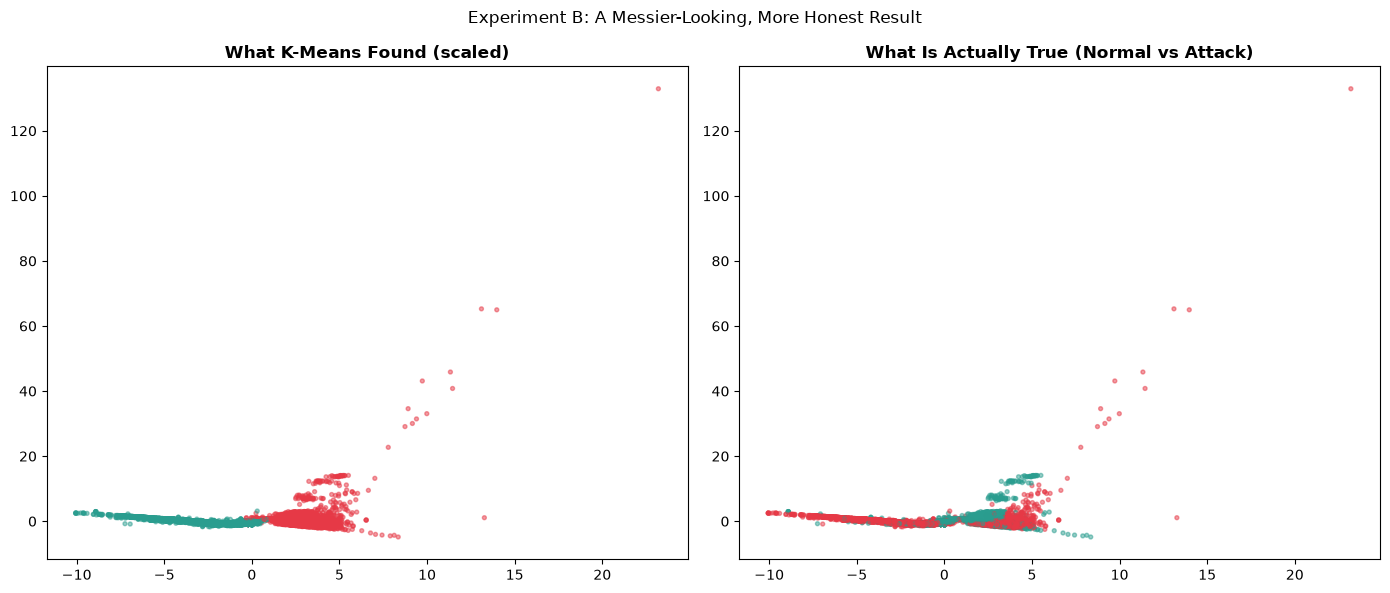

In [22]:
pca_scaled = PCA(n_components=2).fit_transform(X_scaled)
fig, axes = plt.subplots(1,2, figsize=(14,6))
axes[0].scatter(pca_scaled[sample_idx,0], pca_scaled[sample_idx,1], c=[PALETTE[c] for c in clusters_scaled[sample_idx]], s=8, alpha=0.5)
axes[0].set_title('What K-Means Found (scaled)')
axes[1].scatter(pca_scaled[sample_idx,0], pca_scaled[sample_idx,1], c=[PALETTE[c] for c in df['label'].values[sample_idx]], s=8, alpha=0.5)
axes[1].set_title('What Is Actually True (Normal vs Attack)')
plt.suptitle('Experiment B: A Messier-Looking, More Honest Result')
plt.tight_layout()
plt.show()

**Takeaway from Experiment B:** The two shapes above are messier and overlap more than Experiment A's - and that messiness is *closer to the truth*. A lower silhouette score paired with a real, verifiable relationship to reality beats a higher score built on an accident of units. 

## Experiment C: What If We Also Tell It the Network Protocol?

So far K-Means has only seen numbers. Real network monitoring tools also know *which protocol* a connection used, *which service* it was talking to, and *what state* the connection ended in. Let's add all three in, using the cleaned-up 9-bucket version of `proto` from Part 2.

In [23]:
categorical_features = ['proto_bucketed','service','state']
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])
X_processed = preprocessor.fit_transform(df[numeric_features + categorical_features])
X_processed = X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed
X_processed.shape

(175341, 70)

70 columns now (39 scaled numeric + 31 one-hot protocol/service/state columns, instead of the 133+ columns a naive encoding of raw `proto` would have produced).

In [24]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_final = kmeans_final.fit_predict(X_processed)
silhouette_final = silhouette_score(X_processed, clusters_final, sample_size=20000, random_state=42)
pd.DataFrame({'Experiment':['A) Unscaled','B) Scaled (numeric only)','C) Scaled + protocol/service/state'],
              'Silhouette Score':[silhouette_unscaled, silhouette_scaled, silhouette_final]})

,Experiment,Silhouette Score
0,A) Unscaled,0.684864
1,B) Scaled (numeric only),0.305211
2,C) Scaled + protocol/service/state,0.309438


In [25]:
results['cluster_final'] = clusters_final
pd.crosstab(results['cluster_final'], results['label'].map({0:'Normal',1:'Attack'}), normalize='index').round(3)

label,Attack,Normal
cluster_final,,
0,0.816,0.184
1,0.516,0.484


**Takeaway from Experiment C:** almost nothing changed (0.305 -> 0.309, and the attack split barely moved). Adding 31 more columns' worth of network-protocol information didn't meaningfully change what the algorithm found. This is a useful, slightly humbling result in its own right: **more features are not automatically more insight.** The numeric traffic statistics were apparently already carrying most of the signal that protocol/service/state could offer - the extra columns mostly just added noise for K-Means to average out.

## Experiment D: What If We Stop Forcing Just 2 Groups?

Every experiment so far assumed the answer had exactly 2 shapes, because we had "Normal vs. Attack" in mind. But we know from Part 1 that there are actually **9 different attack types plus Normal - 10 categories** hiding behind that binary label. What happens if we let K-Means look for more structure?

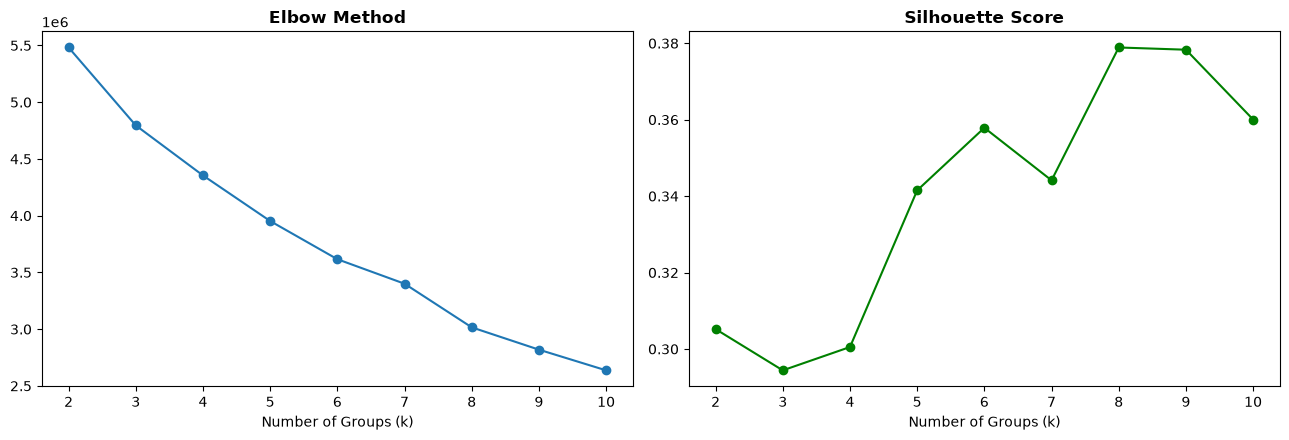

In [26]:
wcss = [KMeans(k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(2,11)]
sil_sweep = [silhouette_score(X_scaled, KMeans(k, random_state=42, n_init=10).fit_predict(X_scaled), sample_size=20000, random_state=42) for k in range(2,11)]
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
axes[0].plot(range(2,11), wcss, marker='o'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('Number of Groups (k)')
axes[1].plot(range(2,11), sil_sweep, marker='o', color='green'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('Number of Groups (k)')
plt.tight_layout()
plt.show()

Silhouette actually **climbs back up** past k=4, reaching its highest point in this range at **k=9** (~0.38 - still modest, but notably better than the forced k=2 attempts). Let's look at what k=9 actually finds.

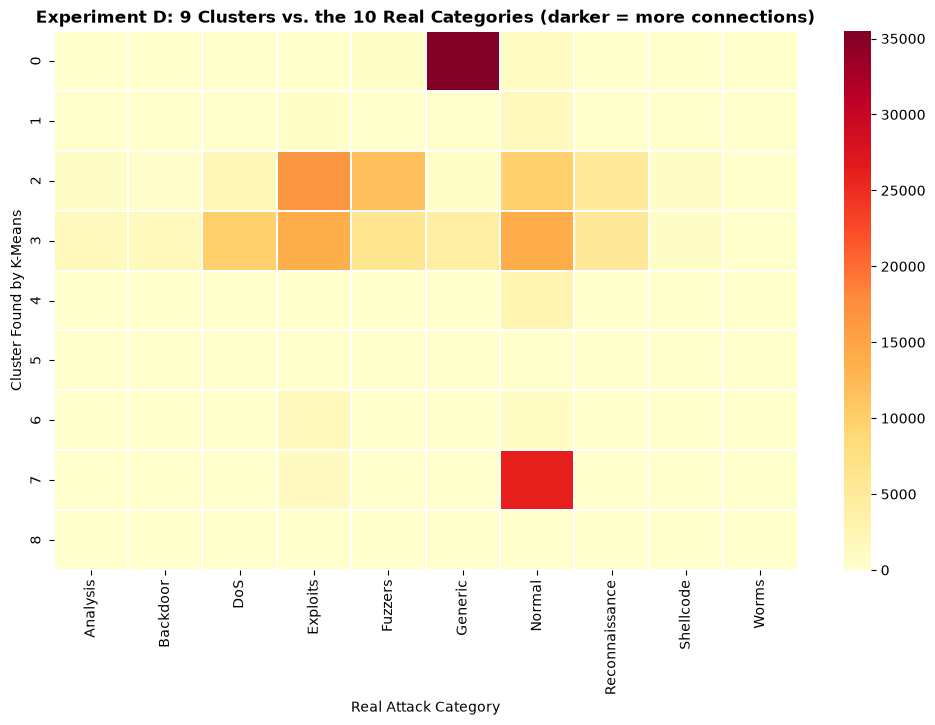

In [27]:
kmeans_9 = KMeans(n_clusters=9, random_state=42, n_init=10)
clusters_9 = kmeans_9.fit_predict(X_scaled)
results['cluster_9'] = clusters_9
ct9 = pd.crosstab(results['cluster_9'], df['attack_cat'])
plt.figure(figsize=(12,7))
sns.heatmap(ct9, cmap='YlOrRd', annot=False, linewidths=0.3)
plt.title('Experiment D: 9 Clusters vs. the 10 Real Categories (darker = more connections)')
plt.xlabel('Real Attack Category'); plt.ylabel('Cluster Found by K-Means')
plt.show()

**This is the most interesting result in the whole notebook, and it's genuinely a different verdict from Experiments A-C:**

- **One cluster (n=36,966) is 96.0% pure `Generic` attacks**, and it captures 88.7% of every single `Generic` attack in the dataset. Generic attacks apparently have a very distinctive network fingerprint - clean enough that an algorithm with zero labels can isolate it almost perfectly.
- **A separate cluster (n=27,375) is 95.4% pure `Normal` traffic** - though it only captures about 47% of all Normal traffic; the rest of Normal is scattered into other, messier clusters.
- The remaining 7 clusters mostly blend together the rarer, more varied attack types (Analysis, Backdoor, DoS, Exploits, Fuzzers, Reconnaissance, Shellcode, Worms) - these don't separate cleanly from each other, which makes sense: they're a much more diverse grab-bag of very different attack techniques than a single binary "attack" label can capture.

**Takeaway from Experiment D:** the *same data*, the *same scaling*, the *same algorithm* gave a murky, barely-better-than-guessing answer at k=2 (Experiments B/C), and then a genuinely striking, verifiable discovery at k=9. The question we chose to ask ("find me 2 groups" vs. "find me 9 groups") mattered as much as any other decision in this entire notebook.

## The Verdict: Four Experiments, Four Different Stories

In [28]:
summary = pd.DataFrame({
    'Experiment': ['A) No scaling (k=2)', 'B) Scaled (k=2)', 'C) Scaled + protocol (k=2)', 'D) Scaled (k=9)'],
    'Silhouette Score': [round(silhouette_unscaled,3), round(silhouette_scaled,3), round(silhouette_final,3), round(sil_sweep[7],3)],
    'Looks Impressive?': ['Yes (very)', 'No', 'No', 'Somewhat'],
    'Actually Matches Reality?': ['Barely - an illusion', 'A little - honest but weak', 'A little - unchanged', 'Yes, for 2 of 10 categories'],
})
summary

,Experiment,Silhouette Score,Looks Impressive?,Actually Matches Reality?
0,A) No scaling (k=2),0.685,Yes (very),Barely - an illusion
1,B) Scaled (k=2),0.305,No,A little - honest but weak
2,C) Scaled + protocol (k=2),0.309,No,A little - unchanged
3,D) Scaled (k=9),0.378,Somewhat,"Yes, for 2 of 10 categories"


Notice the pattern: **the experiment with the best-looking score (A) was the least trustworthy one, and the experiment with a merely-decent score (D) produced the most genuinely useful discovery.** If you only ever look at the headline metric, you'd rank these exactly backwards from how much you should actually trust them.

## What This Experiment Does NOT Prove

Because this touches cybersecurity, it's worth being extra explicit about the boundaries of what happened here - clustering results are easy to over-sell, and security claims deserve extra scrutiny:

- **This is a curated academic dataset, not live network traffic.** 68% of it is labeled an attack; real networks look nothing like that. Nothing here estimates how common attacks are in the real world.
- **K-Means groups connections that *look statistically similar* - it does not understand what an attack *is*.** The "Generic cluster" from Experiment D is a fingerprint made of numbers, not a diagnosis.
- **This is not an intrusion detection system**, and none of these experiments should be read as "K-Means can replace labeled training data or a real security team." Seven of the nine clusters in Experiment D were messy mixtures, not clean discoveries - the two clean ones are the exception, not the rule.
- **A rare category (like Worms, at 130 rows) is too small to draw confident conclusions from**, clustered or not.
- **Correlation is not causation, and clustering finds neither.** A cluster being "81.6% attack" describes a statistical association in this specific dataset, not a mechanism.
- **These results are specific to the features engineered/kept here.** A different feature set - more protocols kept, different columns dropped - could tell a different story again, which is really the whole point of this notebook.

## Key Takeaways (TL;DR)

1. **A great-looking score can be actively misleading.** Experiment A's 0.68 silhouette score was built almost entirely on a meaningless TCP sequence number, not on anything resembling "attack behavior."
2. **Scaling isn't a formality - it changes which story your model tells.** The unscaled and scaled versions of the *exact same data* pointed to two different explanations for the clusters they found.
3. **More features isn't automatically more insight.** Adding 31 columns of protocol/service/state information in Experiment C barely moved the needle.
4. **The question you ask shapes the answer you get.** Forcing a 2-group answer (because we had "Normal vs. Attack" in mind) hid a much clearer, more useful structure that only appeared once we let the algorithm look for 9 groups instead.
5. **Unsupervised learning can find real structure without ever seeing labels** - Experiment D's Generic-attack cluster and mostly-Normal cluster are proof of that - but it finds *statistical patterns*, not *security verdicts*, and most of what it finds will be messier than those two standout clusters.

The headline of this notebook could have been *"AI Detects Cyberattacks With No Training!"* after Experiment A. The honest headline, after all four experiments, is smaller and far more interesting: **the same dataset can support wildly different conclusions depending on choices most people never think to question - whether you scale your data, and how many groups you decide to look for.**